In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [ ]:
region_code='77'
nom_region="Pays_de_la_Loire"


C:\Users\lilym\AppData\Local\Temp\ipykernel_23728\511755371.py:3: DtypeWarning: Columns (158) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(f'DPE_dep_{region_code}.csv')


In [ ]:
df=pd.read_csv(f'DPE_{region_code}.csv')

C:\Users\lilym\AppData\Local\Temp\ipykernel_23728\659428834.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=repartition.index, y=repartition.values, palette="viridis")


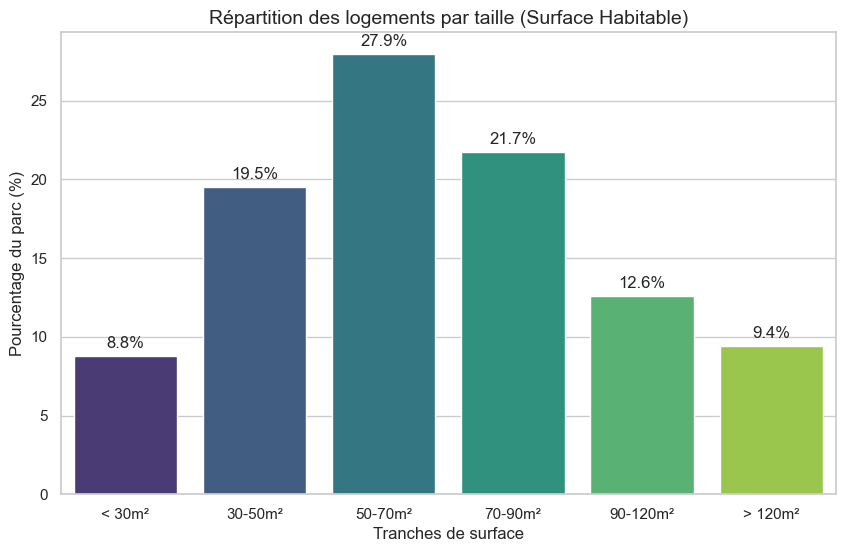

In [21]:
# 1. Définition des tranches de surface (bins)
bins = [0, 30, 50, 70, 90, 120, float('inf')]
labels = ['< 30m²', '30-50m²', '50-70m²', '70-90m²', '90-120m²', '> 120m²']

# 2. Création de la nouvelle colonne de segmentation
# On vérifie si la colonne existe avant de traiter
surface_col = 'surface_habitable_logement'

if surface_col in df.columns:
    # On retire les valeurs aberrantes ou nulles pour le graphique
    df_clean = df[df[surface_col] > 0].copy()
    
    df_clean['tranche_surface'] = pd.cut(df_clean[surface_col], bins=bins, labels=labels)

    # 3. Calcul de la répartition
    repartition = df_clean['tranche_surface'].value_counts(normalize=True).sort_index() * 100

    # 4. Visualisation
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    ax = sns.barplot(x=repartition.index, y=repartition.values, palette="viridis")

    plt.title('Répartition des logements par taille (Surface Habitable)', fontsize=14)
    plt.xlabel('Tranches de surface', fontsize=12)
    plt.ylabel('Pourcentage du parc (%)', fontsize=12)

    # Ajout des étiquettes de pourcentage sur les barres
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    plt.show()
else:
    print(f"La colonne {surface_col} est introuvable. Vérifie le nom exact dans ton dataset.")

In [22]:
# On utilise les noms de colonnes que vous venez de créer/nettoyer
features_cat = [
    'type_batiment', 
    'zone_climatique', 
    'classe_altitude',
    'chauffage_simplifie',        
    'logement_traversant_clean',  
    'isolation_toiture_clean',
    'qualite_isolation_enveloppe',
    'periode_construction',
    'qualite_isolation_murs',
    'qualite_isolation_menuiseries',
    'qualite_isolation_plancher_bas',
    'type_emetteur_installation_chauffage_n1',
    'type_installation_ecs',
    'type_generateur_n1_ecs_n1',
    'presence_brasseur_air',
    'protection_solaire_exterieure',
]

features_num = [
    'surface_habitable_logement',
    'annee_construction', 
    'hauteur_sous_plafond',
    'ubat_w_par_m2_k',
    'besoin_chauffage',
    'apport_solaire_saison_chauffe'
]


target = 'conso_5_usages_ep'

# On récupère la liste des tranches de surface
tranches = df_clean['tranche_surface'].unique()

In [23]:
def entrainer_tranche(df, nom_tranche):
    # 1. Filtrer pour la tranche
    data = df[df['tranche_surface'] == nom_tranche].copy()
    
    data = data.dropna(subset=[target]) 
    data = data[np.isfinite(data[target])] 
    data = data[data[target] > 0]

    if len(data) < 50: # Sécurité : pas de modèle si trop peu de données
        return None
    
    X = data[features_cat + features_num]
    y = data[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 2. Prétraitement (Le OneHotEncoder va créer toutes les colonnes manquantes)
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), features_num),
            ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
        ]
    )
    
    # 3. Le Pipeline XGBoost
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6))
    ])
    
    # 4. Entraînement
    pipeline.fit(X_train, y_train)
    
    # 5. Scores (Modifié ici)
    y_pred = pipeline.predict(X_test) # On stocke les prédictions pour ne les calculer qu'une fois
    
    score_r2 = r2_score(y_test, y_pred)
    score_rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Calcul du RMSE
    
    # On ajoute le RMSE au dictionnaire de retour
    return {'model': pipeline, 'r2': score_r2, 'rmse': score_rmse, 'tranche': nom_tranche}

In [ ]:
import os
import pickle
import pandas as pd

dictionnaire_modeles = {}

# --- CORRECTION 1 : Créer le dossier de la région s'il n'existe pas ---
os.makedirs(nom_region, exist_ok=True)

for t in tranches:
    tranche_clean = t.replace(' ', '').replace('²', '2').replace('<', 'inf').replace('>', 'sup')
    nom_fichier = f"{nom_region}/pipeline_{nom_region}_{tranche_clean}_dpe.pkl"
    
    if os.path.exists(nom_fichier):
        print(f"✅ Le modèle pour {nom_region} ({tranche_clean}) existe déjà ({nom_fichier}). Entraînement annulé.")
        
        # Optionnel : Si le modèle existe déjà, on le charge dans notre dictionnaire pour pouvoir l'utiliser
        with open(nom_fichier, 'rb') as f:
            dictionnaire_modeles[t] = pickle.load(f)

    else:
        print(f"🧠 Entraînement de la tranche : {t}...")
        resultat = entrainer_tranche(df_clean, t)
        
        if resultat:
            pipeline = resultat['model']
            
            # --- CORRECTION 2 : On stocke le modèle dans le dictionnaire ---
            dictionnaire_modeles[t] = pipeline
            
            # --- ÉTAPE 2 : Sauvegarde immédiate du fichier .pkl ---
            with open(nom_fichier, 'wb') as f:
                pickle.dump(pipeline, f)
                
            print(f"💾 Nouveau modèle sauvegardé sous : {nom_fichier} (R2: {resultat['r2']:.4f})")

            # 1. Récupération de vos métriques
            score_r2 = resultat['r2']
            score_rmse = resultat['rmse']

            # 2. Création d'un petit DataFrame avec les résultats de cette région
            nouvelle_ligne = pd.DataFrame({
                'Region': [nom_region],       # La variable définie par Papermill
                'Tranche': [t],
                'Type': ['DPE'],              # Le nom de votre algorithme
                'R2_Score': [score_r2],
                'RMSE': [score_rmse]
            })

            # 3. Nom du fichier CSV central qui va regrouper tous les résultats
            fichier_resultats = 'performances_modeles.csv'

            # 4. Sauvegarde dans le CSV (avec la logique d'ajout)
            if not os.path.exists(fichier_resultats):
                nouvelle_ligne.to_csv(fichier_resultats, index=False)
            else:
                nouvelle_ligne.to_csv(fichier_resultats, mode='a', header=False, index=False)

            print(f"📊 Résultats sauvegardés pour {nom_region} ({t}) ! (R²: {score_r2:.3f}, RMSE: {score_rmse:.0f})\n")
            
        else:
            # CORRECTION 3 : Savoir quand une tranche échoue
            print(f"⚠️ Pas assez de données (ou erreur) pour la tranche {t}. Aucun modèle sauvegardé.\n")


# Exemple pour tester un modèle à la fin de la boucle (ex: la tranche '40-60')
# dictionnaire_modeles['40-60'].predict(un_nouveau_logement_brut)

💾 Nouveau modèle sauvegardé sous : pipeline_Pays_de_la_Loire_90-120m2_dpe.pkl
Entraînement de la tranche : 90-120m²...
📊 Résultats sauvegardés pour Pays_de_la_Loire ! (R²: 0.897, RMSE: 3202)
💾 Nouveau modèle sauvegardé sous : pipeline_Pays_de_la_Loire_70-90m2_dpe.pkl
Entraînement de la tranche : 70-90m²...
📊 Résultats sauvegardés pour Pays_de_la_Loire ! (R²: 0.897, RMSE: 2331)
💾 Nouveau modèle sauvegardé sous : pipeline_Pays_de_la_Loire_50-70m2_dpe.pkl
Entraînement de la tranche : 50-70m²...
📊 Résultats sauvegardés pour Pays_de_la_Loire ! (R²: 0.893, RMSE: 1854)
💾 Nouveau modèle sauvegardé sous : pipeline_Pays_de_la_Loire_inf30m2_dpe.pkl
Entraînement de la tranche : < 30m²...
📊 Résultats sauvegardés pour Pays_de_la_Loire ! (R²: 0.921, RMSE: 786)
💾 Nouveau modèle sauvegardé sous : pipeline_Pays_de_la_Loire_sup120m2_dpe.pkl
Entraînement de la tranche : > 120m²...
📊 Résultats sauvegardés pour Pays_de_la_Loire ! (R²: 0.891, RMSE: 7011)
💾 Nouveau modèle sauvegardé sous : pipeline_Pays_de_la